In [1]:
import random
import time
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from typing import List
import ast

pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 1000)

In [2]:
cd ../

/Users/asxvi/Desktop/uic/research/audb/extension/experimentRunner


In [3]:
def load_all_csvs(csv_paths: List[str]) -> pd.DataFrame:
    """Load and combine multiple experiment CSVs."""
    dfs = []
    for path in csv_paths:
        df = pd.read_csv(path, index_col=0)
        df['source_file'] = Path(path).parent.name  # track which experiment it came from
        dfs.append(df)
    
    combined = pd.concat(dfs, ignore_index=True)
    
    # add in tuple representation vs string for convenience
    combined[['resizeTrigger', 'sizeLimit']] = combined['reduce_triggerSz_sizeLim'].str.strip('()').str.split(',', expand=True).astype(int)
    combined['gap_size_range_tuple'] = combined['gap_size_range'].apply(ast.literal_eval)
    combined['reduce_triggerSz_sizeLim_tuple'] = combined['reduce_triggerSz_sizeLim'].apply(ast.literal_eval)
    return combined


def get_dataset_size_bounds(df: pd.DataFrame) -> str:
    sizes = sorted(df['dataset_size'].unique())
    min_n = sizes[0]
    max_n = sizes[-1]
    if len(sizes) > 1:
        step_n = sizes[1] - sizes[0]
    else:
        step_n = 0
    
    return f"{min_n}..{max_n} step {step_n}"


In [4]:
csv_paths = ['data/results/3025698100/ni_gap_sweep_n2k/ni_gap_red15_10_sweep/results_sd3025698100.csv', 'data/results/3025698100/ni_gap_sweep_n2k/ni_gap_red3_1_sweep/results_sd3025698100.csv']
df = load_all_csvs(csv_paths)
df
df_filtered = df[
    df['reduce_triggerSz_sizeLim_tuple'] == (15, 10)
]
df_filtered

,master_seed,data_type,num_trials,dataset_size,uncertain_ratio,interval_size_range,mult_size_range,num_intervals,gap_size,interval_width,num_intervals_range,gap_size_range,interval_width_range,reduce_triggerSz_sizeLim,independent_variable,min_time_mean,min_time_std,max_time_mean,max_time_std,sum_time_mean,sum_time_std,sumtest_time_mean,sumtest_time_std,reduce_calls_mean,max_interval_count_mean,total_interval_count_mean,combine_calls_mean,result_size_mean,minEffectiveIntervalCountMean,convergedToTotSize,result_coverage_mean,source_file,resizeTrigger,sizeLimit,gap_size_range_tuple,reduce_triggerSz_sizeLim_tuple
0,3025698100,set,5,100,0.0,"(1, 100000)","(1, 5)",5,NaN,NaN,NaN,"(10, 11)","(5, 6)","(15, 10)",gap_size_range,0.1798,0.010147,0.1914,0.024138,0.1974,0.011859,0.1890,0.010257,50.0,45.0,1520.0,100.0,1.0,1.0,6501.0,6501.0,ni_gap_red15_10_sweep,15,10,"(10, 11)","(15, 10)"
1,3025698100,set,5,100,0.0,"(1, 100000)","(1, 5)",5,NaN,NaN,NaN,"(50, 51)","(5, 6)","(15, 10)",gap_size_range,0.1784,0.001020,0.1766,0.000800,0.2170,0.023698,0.1912,0.008035,54.0,50.0,1800.0,100.0,1.0,1.0,22501.0,22501.0,ni_gap_red15_10_sweep,15,10,"(50, 51)","(15, 10)"
2,3025698100,set,5,100,0.0,"(1, 100000)","(1, 5)",5,NaN,NaN,NaN,"(100, 101)","(5, 6)","(15, 10)",gap_size_range,0.1770,0.002898,0.1792,0.008447,0.2218,0.015613,0.2182,0.013526,59.0,50.0,2150.0,100.0,1.0,1.0,42501.0,42501.0,ni_gap_red15_10_sweep,15,10,"(100, 101)","(15, 10)"
3,3025698100,set,5,100,0.0,"(1, 100000)","(1, 5)",5,NaN,NaN,NaN,"(250, 251)","(5, 6)","(15, 10)",gap_size_range,0.1740,0.006542,0.1744,0.010052,0.3118,0.097136,0.2424,0.011324,74.0,50.0,3200.0,100.0,1.0,1.0,102501.0,102501.0,ni_gap_red15_10_sweep,15,10,"(250, 251)","(15, 10)"
4,3025698100,set,5,100,0.0,"(1, 100000)","(1, 5)",5,NaN,NaN,NaN,"(500, 501)","(5, 6)","(15, 10)",gap_size_range,0.1866,0.007419,0.1830,0.008854,0.3508,0.036815,0.3302,0.011973,99.0,50.0,4925.0,100.0,10.0,10.0,202465.0,202465.0,ni_gap_red15_10_sweep,15,10,"(500, 501)","(15, 10)"
5,3025698100,set,5,100,0.0,"(1, 100000)","(1, 5)",5,NaN,NaN,NaN,"(10000, 10001)","(5, 6)","(15, 10)",gap_size_range,0.1754,0.005713,0.1738,0.005418,0.3386,0.015603,0.3174,0.004224,99.0,50.0,4925.0,100.0,10.0,10.0,3916965.0,3916965.0,ni_gap_red15_10_sweep,15,10,"(10000, 10001)","(15, 10)"
6,3025698100,set,5,100,0.0,"(1, 100000)","(1, 5)",5,NaN,NaN,NaN,"(20000, 20001)","(5, 6)","(15, 10)",gap_size_range,0.1834,0.015253,0.1792,0.009325,0.3470,0.031068,0.3192,0.016042,99.0,50.0,4925.0,100.0,10.0,10.0,7826965.0,7826965.0,ni_gap_red15_10_sweep,15,10,"(20000, 20001)","(15, 10)"
7,3025698100,set,5,200,0.0,"(1, 100000)","(1, 5)",5,NaN,NaN,NaN,"(10, 11)","(5, 6)","(15, 10)",gap_size_range,0.3766,0.059153,0.3914,0.096817,0.5158,0.223929,0.3558,0.068849,100.0,45.0,3020.0,200.0,1.0,1.0,13001.0,13001.0,ni_gap_red15_10_sweep,15,10,"(10, 11)","(15, 10)"
8,3025698100,set,5,200,0.0,"(1, 100000)","(1, 5)",5,NaN,NaN,NaN,"(50, 51)","(5, 6)","(15, 10)",gap_size_range,0.3284,0.009952,0.3284,0.008212,0.3442,0.017337,0.3150,0.005550,104.0,50.0,3300.0,200.0,1.0,1.0,45001.0,45001.0,ni_gap_red15_10_sweep,15,10,"(50, 51)","(15, 10)"
9,3025698100,set,5,200,0.0,"(1, 100000)","(1, 5)",5,NaN,NaN,NaN,"(100, 101)","(5, 6)","(15, 10)",gap_size_range,0.3310,0.005099,0.3258,0.005192,0.3802,0.061431,0.3290,0.014765,109.0,50.0,3650.0,200.0,1.0,1.0,85001.0,85001.0,ni_gap_red15_10_sweep,15,10,"(100, 101)","(15, 10)"


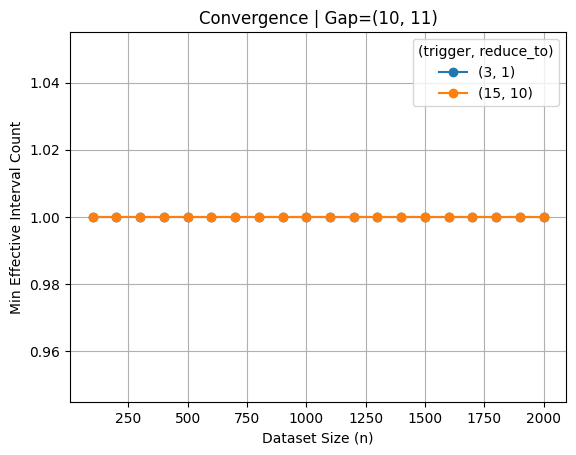

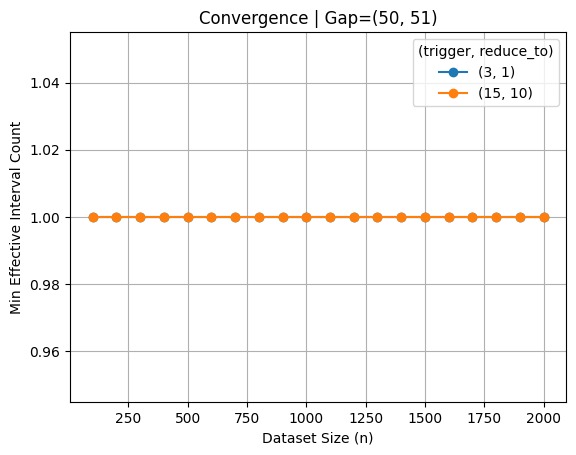

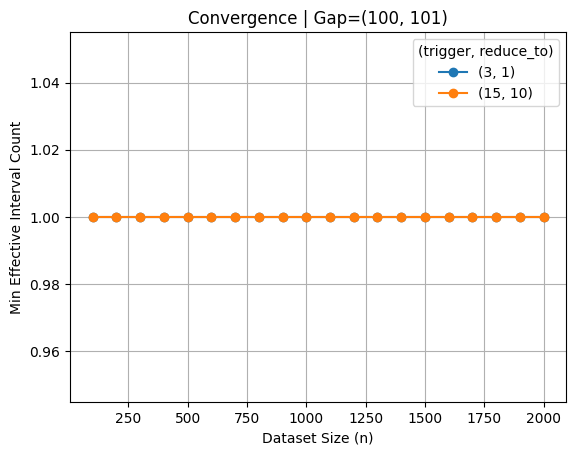

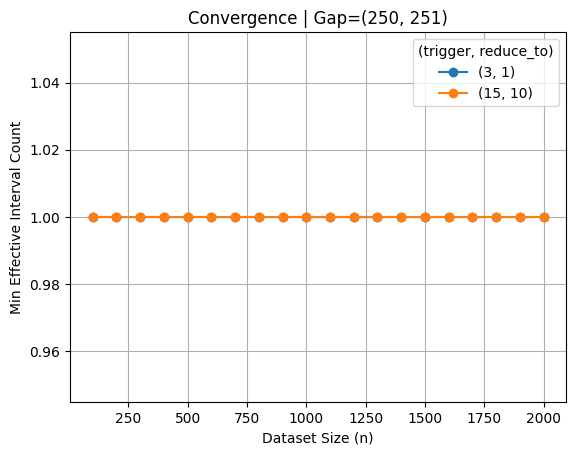

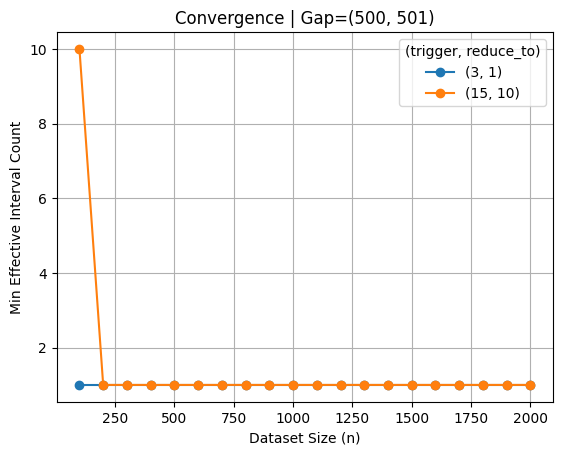

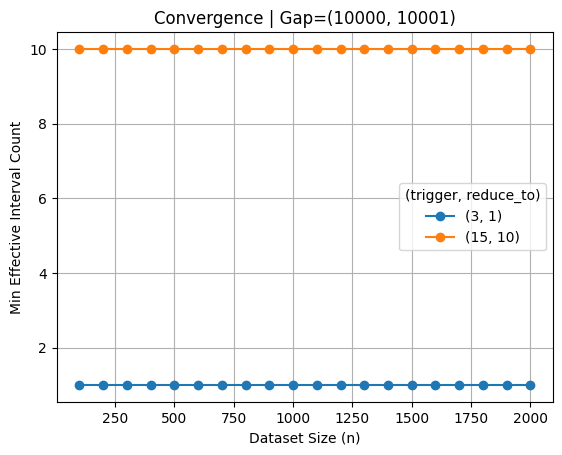

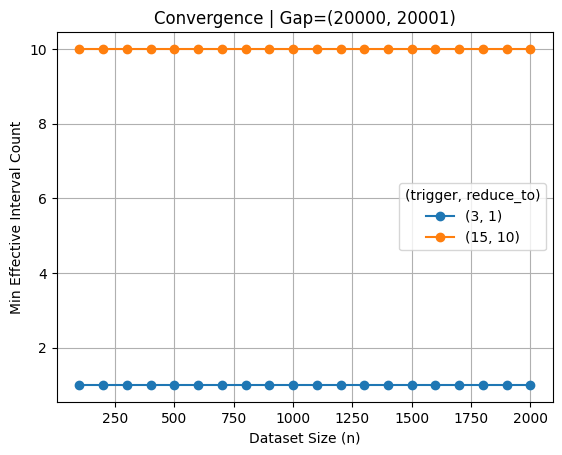

In [5]:
def plot_by_gap(df):
    gaps = sorted(df['gap_size_range_tuple'].unique())
    reduce_params = sorted(
        df[['resizeTrigger', 'sizeLimit']]
        .drop_duplicates()
        .itertuples(index=False, name=None)
    )

    for gap in gaps:
        plt.figure()

        gap_df = df[df['gap_size_range_tuple'] == gap]

        for trigger, size_limit in reduce_params:
            subdf = gap_df[
                (gap_df['resizeTrigger'] == trigger) &
                (gap_df['sizeLimit'] == size_limit)
            ].sort_values('dataset_size')

            if subdf.empty:
                continue

            plt.plot(
                subdf['dataset_size'],
                subdf['minEffectiveIntervalCountMean'],
                marker='o',
                label=f'({trigger}, {size_limit})'
            )

        plt.xlabel("Dataset Size (n)")
        plt.ylabel("Min Effective Interval Count")
        plt.title(f"Convergence | Gap={gap}")
        plt.legend(title="(trigger, reduce_to)")
        plt.grid(True)
        plt.show()

plot_by_gap(df)

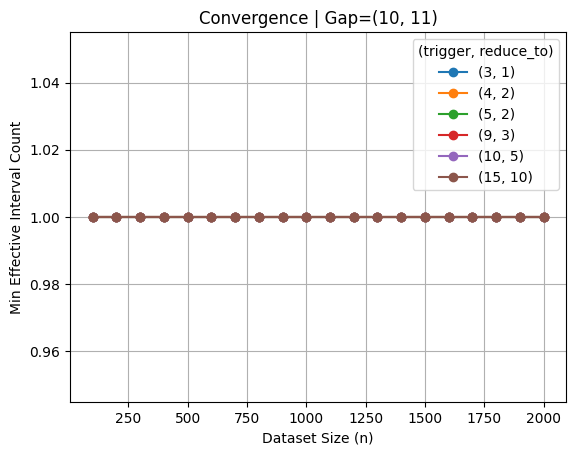

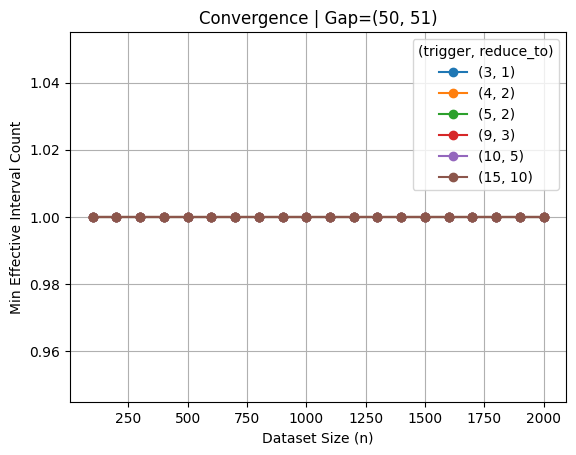

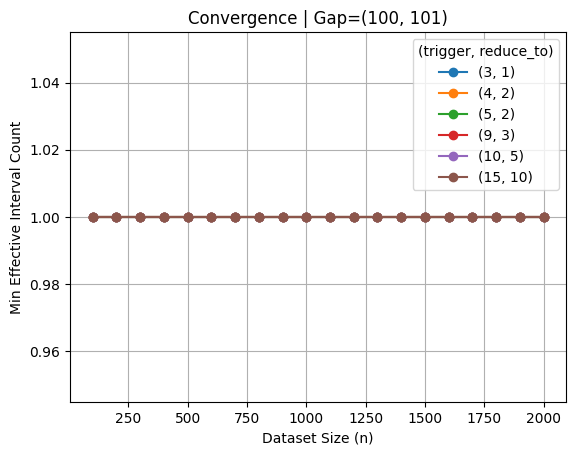

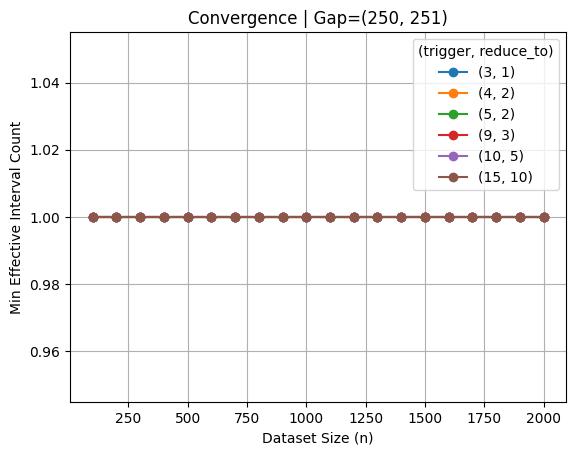

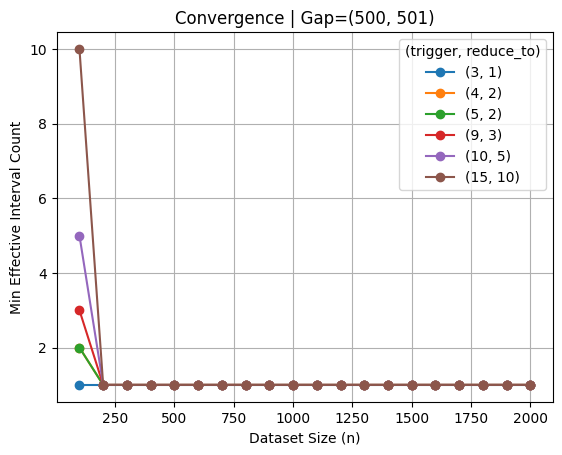

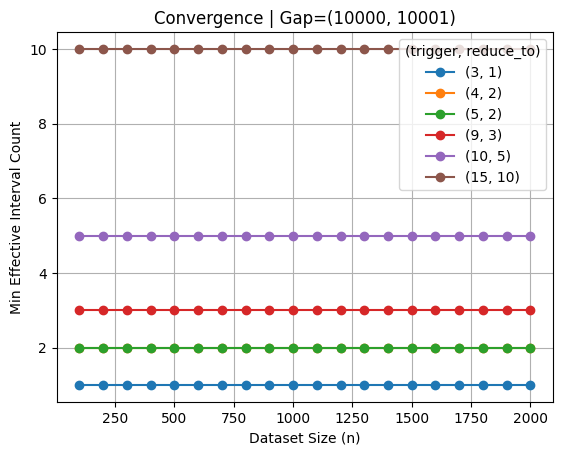

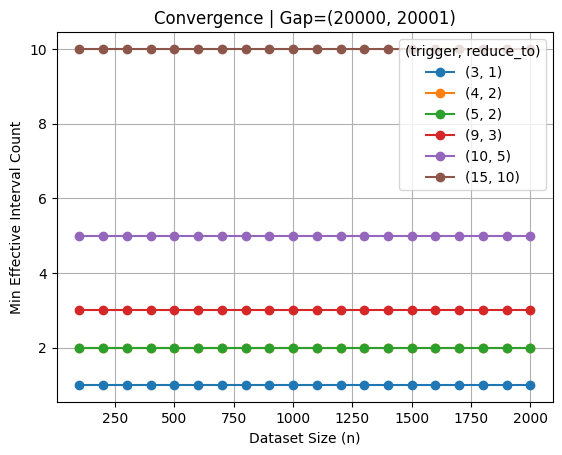

In [6]:
csv_paths2 = ['data/results/3037411030/ni_gap_sweep_n2k/ni_gap_red15_10_sweep/results_sd3037411030.csv', 'data/results/3037411030/ni_gap_sweep_n2k/ni_gap_red10_5_sweep/results_sd3037411030.csv', 'data/results/3037411030/ni_gap_sweep_n2k/ni_gap_red4_2_sweep/results_sd3037411030.csv', 'data/results/3037411030/ni_gap_sweep_n2k/ni_gap_red9_3_sweep/results_sd3037411030.csv', 'data/results/3037411030/ni_gap_sweep_n2k/ni_gap_red5_2_sweep/results_sd3037411030.csv', 'data/results/3037411030/ni_gap_sweep_n2k/ni_gap_red3_1_sweep/results_sd3037411030.csv']
df2 = load_all_csvs(csv_paths2)
plot_by_gap(df2)